
# ¿Qué es una Red Neuronal Recurrente (RNN) y por qué existe? 🔁🧠

Este notebook es **conceptual** y sirve como puerta de entrada antes de pasar al cálculo manual y al código.

Aquí vas a entender:

- qué cambia en la arquitectura cuando pasamos de una red “clásica” (feedforward) a una RNN,
- qué significa “memoria” en términos de **estado oculto**,
- qué es el “desenrollado” (unrolling) en el tiempo,
- por qué aparece el **gradiente desvaneciente**,
- y cómo LSTM introduce **compuertas** (gates) para controlar el olvido y la escritura de memoria.



## 1) Recordatorio: feedforward ≠ secuencia

En una red feedforward (MLP), cada ejemplo se procesa “de una vez”:

- entrada $x$ → capas → salida $\hat{y}$

Pero en datos secuenciales, el **orden importa**:

- series de tiempo (ventas, clima, GMV, precios)
- texto (palabras en orden)
- audio (señal temporal)

📌 Problema: si procesas solo el último valor $x_t$, pierdes el contexto: $x_{t-1}, x_{t-2}, ...$



## 2) La idea central de una RNN: estado oculto (memoria)

Una RNN procesa una secuencia paso a paso y mantiene un **estado oculto** \(h_t\).

En cada instante $t$, la red mezcla:

- lo nuevo: $x_t$
- lo que “recuerda”: $h_{t-1}$

Ecuación típica (RNN simple):

$$
h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)
$$

$$
\hat{y}_t = W_{hy} h_t + b_y
$$

### Intuición BI
$h_t$ es un **resumen comprimido** del pasado, como un “estado del sistema” que se va actualizando.



## 3) Diagrama: feedforward vs RNN (Mermaid)

### 3.1 Feedforward (una sola entrada)

```{mermaid}
flowchart LR
  X[x] --> H[Capas ocultas] --> Y[ŷ]
```

### 3.2 RNN (recurrente)

```{mermaid}
flowchart LR
  Xt["x(t)"] --> Ht["h(t)"]
  Hprev["h(t-1)"] --> Ht
  Ht --> Yt["y_hat(t)"]
  Ht --> Hnext["h(t+1)"]
```



## 4) “Desenrollado” en el tiempo (Unrolling)

Entrenar una RNN se entiende mejor si la “desenrollas”:

- la misma celda se repite para \(t=1,2,3,...\)
- los pesos \(W_{xh}, W_{hh}\) se **comparten** en todos los tiempos

```{mermaid}
flowchart LR
  X1[x_1] --> H1[h_1] --> H2[h_2] --> H3[h_3]
  X2[x_2] --> H2
  X3[x_3] --> H3
  H1 --> Y1[ŷ_1]
  H2 --> Y2[ŷ_2]
  H3 --> Y3[ŷ_3]
```

📌 Esto explica por qué el entrenamiento se llama **Backpropagation Through Time (BPTT)**:
el error se propaga desde el final hacia atrás, atravesando los pasos temporales.



## 5) El problema del gradiente desvaneciente (y explotante)

Durante BPTT, la señal de gradiente se multiplica repetidamente por términos relacionados con:

- derivadas de activación (tanh/sigmoid)
- la matriz recurrente $W_{hh}$

Si esas multiplicaciones tienden a producir valores menores que 1, el gradiente se hace muy pequeño:

$$
0.1 \times 0.1 \times \dots \approx 0
$$

**Consecuencia:** la red aprende sobre todo de lo reciente → “memoria corta”.

También puede pasar lo contrario (gradiente muy grande): **gradiente explotante**.



## 6) ¿Cómo lo arregla LSTM? Memoria + compuertas

LSTM añade un estado extra: **estado de celda** $c_t$, pensado como una autopista de memoria.

La actualización se controla con **compuertas** (valores entre 0 y 1 con sigmoide):

- **Forget gate** $f_t$: qué parte de $c_{t-1}$ se conserva
- **Input gate** $i_t$: qué parte de la información nueva se escribe
- **Output gate** $o_t$: qué parte de la memoria se expone como $h_t$

Ecuaciones (forma estándar):

$$
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
$$

$$
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

$$
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \odot \tanh(c_t)
$$

> \(\odot\) es producto elemento a elemento.



## 7) Diagrama conceptual de LSTM (Mermaid)

Este diagrama no pretende ser “electrónico” sino pedagógico:

```{mermaid}
flowchart LR

  subgraph Cell["LSTM cell (time t)"]

    Xt["x(t)"] --> G1["Input gate i(t)"]
    Xt --> G2["Forget gate f(t)"]
    Xt --> G3["Output gate o(t)"]

    Hprev["h(t-1)"] --> G1
    Hprev --> G2
    Hprev --> G3

    Cprev["c(t-1)"] --> Update["Update memory"]
    G2 --> Update
    G1 --> Update

    Update --> Ct["c(t)"]
    Ct --> Out["Compute h(t)"]
    G3 --> Out
    Out --> Ht["h(t)"]

  end

  Ct --> Cnext["c(t+1)"]
  Ht --> Hnext["h(t+1)"]
```



## 8) ¿Qué “aprende” una compuerta?

Piensa en compuertas como **decisiones suaves**:

- si $f_t \approx 1$ → conservas memoria
- si $f_t \approx 0$ → olvidas
- si $i_t \approx 1$ → escribes información nueva
- si $o_t \approx 1$ → expones más memoria a la salida

Eso hace a LSTM muy útil para patrones con distintos horizontes:

- corto plazo (ruido, cambios recientes)
- largo plazo (estacionalidad, ciclos, eventos importantes)



## 9) Conexión con los notebooks del curso

Con esto ya estás listo para:

1) **Notebook 1:** sesión manual (ver el flujo de memoria con números)  
2) **Notebook 2:** clase `SimpleRNN` (construir el “cerebro” en NumPy)  
3) **Notebook 3:** caso café con SimpleRNN (pipeline + evaluación)  
4) **Notebook 4:** caso café con LSTM (comparativa vs SimpleRNN)  
5) **Notebook 5:** BTC con BiLSTM (volatilidad + baseline + modo offline)

📌 Este notebook (definiciones + diagramas) es el mejor “arranque” para que los estudiantes entiendan el mapa general.


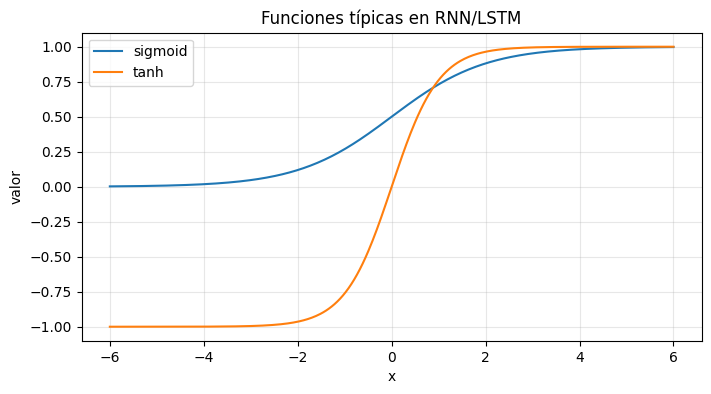

In [1]:

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(8, 4))
plt.plot(x, sigmoid, label="sigmoid")
plt.plot(x, tanh, label="tanh")
plt.title("Funciones típicas en RNN/LSTM")
plt.xlabel("x")
plt.ylabel("valor")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
